In [1]:
# torch is already present on the A100 image; add the video reader + plotting
!pip -q install decord matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 117.4 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/Sid430/cataract-videomae-pretrain.git


Cloning into 'cataract-videomae-pretrain'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 34 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 30.38 MiB | 15.39 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [3]:
%cd /content/cataract-videomae-pretrain

/content/cataract-videomae-pretrain


In [4]:
!wget -O /content/data.tar "https://www.dropbox.com/scl/fi/igderi5zi2l80ujxsajt8/CataractVidoes4ssl.tar?rlkey=j6n9bs6sp2vfcy07cl1n1z78i&dl=1"


--2026-07-05 01:53:50--  https://www.dropbox.com/scl/fi/igderi5zi2l80ujxsajt8/CataractVidoes4ssl.tar?rlkey=j6n9bs6sp2vfcy07cl1n1z78i&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:6022:18::a27d:4212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc5e680e7e8c6ddce825fb03921f.dl.dropboxusercontent.com/cd/0/inline/DDoDqQQsdShIPU6abecOpENTcariTNFqAsh-vqf1rwf4qjsbY3LYn4sLmPxE6diaChFTVn0VrHhBjAH-HFQoN41XaDYZ8AE4aIRfppmlOVTcSDD53iDfX_k9ke6Lm0FTmDIjNRa9XDtra66nKX-y-yIu/file?dl=1# [following]
--2026-07-05 01:53:51--  https://uc5e680e7e8c6ddce825fb03921f.dl.dropboxusercontent.com/cd/0/inline/DDoDqQQsdShIPU6abecOpENTcariTNFqAsh-vqf1rwf4qjsbY3LYn4sLmPxE6diaChFTVn0VrHhBjAH-HFQoN41XaDYZ8AE4aIRfppmlOVTcSDD53iDfX_k9ke6Lm0FTmDIjNRa9XDtra66nKX-y-yIu/file?dl=1
Resolving uc5e680e7e8c6ddce825fb03921f.dl.dropboxusercontent.com (uc5e680e7e8c6ddce825fb03921f.dl.dropboxusercontent.co

In [6]:
!mkdir -p /content/cataract-videomae-pretrain/data


In [7]:
!tar -xf /content/data.tar -C /content/cataract-videomae-pretrain/data


In [9]:
!ls /content/cataract-videomae-pretrain/data/moha_Raw_Videos_4SSL | head


case_2000.mp4
case_2001.mp4
case_2002.mp4
case_2003.mp4
case_2004.mp4
case_2005.mp4
case_2006.mp4
case_2007.mp4
case_2008.mp4
case_2009.mp4


In [10]:
!echo "files:" && ls /content/cataract-videomae-pretrain/data/moha_Raw_Videos_4SSL/*.mp4 | wc -l


files:
2742


In [11]:
import torch
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [24]:
# Point DATA_ROOT at the folder containing all the .mp4 videos.
# Use an absolute path if the notebook isn't in the same dir as the data.
DATA_ROOT = "data/moha_Raw_Videos_4SSL"
OUT_DIR   = "checkpoints"      # checkpoints + metrics + learning_curve.pdf go here

MODEL       = "base"           # ViT-B/16
BATCH_SIZE  = 64
EPOCHS      = 800
IMG_SIZE    = 224
NUM_FRAMES  = 16

import os
os.makedirs(OUT_DIR, exist_ok=True)
print("data root:", os.path.abspath(DATA_ROOT))
print("output dir:", os.path.abspath(OUT_DIR))

data root: /content/cataract-videomae-pretrain/data/moha_Raw_Videos_4SSL
output dir: /content/cataract-videomae-pretrain/checkpoints


In [25]:
import os
print("cwd:", os.getcwd())
print("contents:", os.listdir("."))

cwd: /content/cataract-videomae-pretrain
contents: ['pretrain.ipynb', 'models', 'checkpoints', 'pretrain.py', 'data', 'check_data.py', 'configs', '__pycache__', 'plot_utils.py', '.ipynb_checkpoints', '.git', 'README.md']


In [26]:
import sys; sys.path.append(".")
from data.datasets import CataractVideoDataset

ds = CataractVideoDataset(DATA_ROOT, mode="video",
                          num_frames=NUM_FRAMES, img_size=IMG_SIZE, sampling_stride=4)
print("backend:", ds.backend, "| clips found:", len(ds))
clip = ds[0]
print("sample clip shape:", tuple(clip.shape), "dtype:", clip.dtype,
      "min %.2f max %.2f" % (clip.min(), clip.max()))
assert tuple(clip.shape) == (3, NUM_FRAMES, IMG_SIZE, IMG_SIZE), "unexpected clip shape"
print("OK - ready to train")

backend: decord | clips found: 2742
sample clip shape: (3, 16, 224, 224) dtype: torch.float32 min -2.12 max 2.64
OK - ready to train


In [27]:
cmd = f'''python pretrain.py \
  --data-root "{DATA_ROOT}" --data-mode video \
  --model {MODEL} --batch-size {BATCH_SIZE} --epochs {EPOCHS} \
  --img-size {IMG_SIZE} --num-frames {NUM_FRAMES} \
  --amp --num-workers 8 \
  --early-stop-patience 15 --early-stop-min-delta 1e-4 \
  --out-dir "{OUT_DIR}"'''
print(cmd)
get_ipython().system(cmd)

python pretrain.py   --data-root "data/moha_Raw_Videos_4SSL" --data-mode video   --model base --batch-size 64 --epochs 800   --img-size 224 --num-frames 16   --amp --num-workers 8   --early-stop-patience 15 --early-stop-min-delta 1e-4   --out-dir "checkpoints"
[model] VideoMAE-v2-base | 94.2M params | 1568 tokens | device=cuda
  epoch 0 step 10/42 loss 0.8613 lr 8.93e-07
  epoch 0 step 20/42 loss 0.8487 lr 1.79e-06
  epoch 0 step 30/42 loss 0.8293 lr 2.68e-06
  epoch 0 step 40/42 loss 0.8394 lr 3.57e-06
[epoch 0] avg_loss 0.8518 time 124.7s
  epoch 1 step 8/42 loss 0.8211 lr 4.46e-06
  epoch 1 step 18/42 loss 0.8325 lr 5.36e-06
  epoch 1 step 28/42 loss 0.8284 lr 6.25e-06
  epoch 1 step 38/42 loss 0.7824 lr 7.14e-06
[epoch 1] avg_loss 0.8153 time 125.2s
  epoch 2 step 6/42 loss 0.7712 lr 8.04e-06
  epoch 2 step 16/42 loss 0.7564 lr 8.93e-06
  epoch 2 step 26/42 loss 0.7478 lr 9.82e-06
  epoch 2 step 36/42 loss 0.7381 lr 1.07e-05
[epoch 2] avg_loss 0.7567 time 122.6s
  epoch 3 step 4/42

logged 14154 steps across 337 epochs


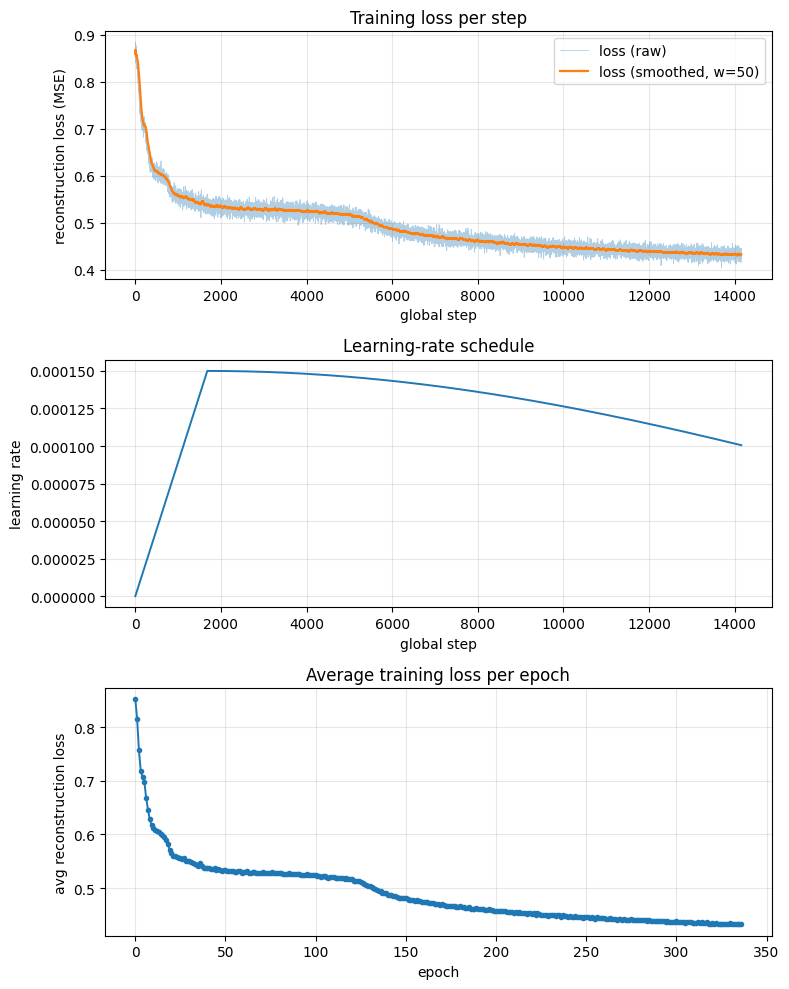

[plot] wrote checkpoints/learning_curve.pdf


'checkpoints/learning_curve.pdf'

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
from plot_utils import load_step_metrics, load_epoch_metrics, _smooth, make_curves_pdf

steps  = load_step_metrics(OUT_DIR)
epochs = load_epoch_metrics(OUT_DIR)
print(f"logged {len(steps)} steps across {len(epochs)} epochs")

SMOOTH = 50
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

if steps:
    gs = [r["gstep"] for r in steps]; ls = [r["loss"] for r in steps]
    axes[0].plot(gs, ls, lw=0.6, alpha=0.35, label="loss (raw)")
    axes[0].plot(gs, _smooth(ls, SMOOTH), lw=1.6, label=f"loss (smoothed, w={SMOOTH})")
    axes[0].set(xlabel="global step", ylabel="reconstruction loss (MSE)",
                title="Training loss per step"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(gs, [r["lr"] for r in steps], lw=1.4)
    axes[1].set(xlabel="global step", ylabel="learning rate",
                title="Learning-rate schedule"); axes[1].grid(alpha=0.3)

if epochs:
    axes[2].plot([e["epoch"] for e in epochs], [e["avg_loss"] for e in epochs],
                 marker="o", ms=3, lw=1.4)
    axes[2].set(xlabel="epoch", ylabel="avg reconstruction loss",
                title="Average training loss per epoch"); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# also refresh the saved PDF
make_curves_pdf(OUT_DIR)

In [29]:
import shutil
shutil.make_archive("/content/checkpoints", "zip", "checkpoints")

from google.colab import files
files.download("/content/checkpoints.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>